# AFINs as proposals

AFINs are useful in two modes:

1. **One-shot posterior approximation**: use the decoded posterior directly.
2. **Corrected proposal**: use an AFIN as a proposal inside SNIS or independence MH.

This notebook focuses on the second mode. The target is a small mixed-likelihood 2D Bayesian model, so we can compare proposal samples, corrected samples, and a NUTS reference visually.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "afin").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

import importlib
import afin
import afin.api as _afin_api
import afin.inference as _afin_inference
import afin.proposals as _afin_proposals
import afin.spec as _afin_spec

importlib.reload(_afin_spec)
importlib.reload(_afin_inference)
importlib.reload(_afin_api)
importlib.reload(_afin_proposals)
afin = importlib.reload(afin)
from afin import (
    AFIN,
    NumPyroNUTS,
    GaussianPrior,
    LinearGaussian,
    BernoulliLogit,
    LinearStudentT,
    SamplePosterior,
    chain_metric_trace,
    infer,
    make_mixed_2d_data,
    plot_2d,
    posterior_metric_line,
    run_afin_imh,
    run_random_walk_mh,
    snis_from_afin,
)

_ = torch.manual_seed(0)
NUTS_KWARGS = dict(num_warmup=1_000, platform="cpu", progress_bar=True)

## Bayesian task

We write the mixed 2D model once as a prior plus observed likelihood factors. Below, AFIN and NUTS differ only in the first argument to `infer(...)`.

In [2]:
data = make_mixed_2d_data(seed=4, n_gaussian=18, n_binary=18, n_student=18)

prior = GaussianPrior(loc=0, scale=1)
observed = [
    LinearGaussian(design_matrix=data["X_gauss"], sigma=0.35).observe(data["y_gauss"]),
    BernoulliLogit(design_matrix=data["X_binary"]).observe(data["y_binary"]),
    LinearStudentT(design_matrix=data["X_student"], sigma=0.60, df=4).observe(data["y_student"]),
]

## AFIN proposal and NUTS reference

The checkpoint is downloaded from Hugging Face the first time this cell runs and then reused from the local cache.

In [3]:
flow = AFIN("flow")

proposal = infer(flow, prior, observed, num_samples=4_000, seed=19, log_prob=True)

reference = infer(NumPyroNUTS(**NUTS_KWARGS), proposal.target, num_samples=6_000, seed=0)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Starting AFIN flow...
Finished AFIN flow in 0.44 seconds.
Starting NumPyro NUTS...


sample: 100%|██████████| 7000/7000 [00:02<00:00, 2581.66it/s, 3 steps of size 1.05e+00. acc. prob=0.88] 


Finished NumPyro NUTS in 13.2 seconds.


## SNIS: AFIN proposal, then importance correction

The flow posterior family already gives a useful proposal. SNIS reweights those samples by

$$
w_i \propto \frac{p(z_i, y)}{q_\phi(z_i)}.
$$

If the proposal is good, the effective sample size stays high and the corrected posterior moves closer to the NUTS reference.

In [4]:
snis = snis_from_afin(flow, proposal.target, n=4_000, seed=19)

print(posterior_metric_line(proposal, reference, approx_time=proposal.runtime_seconds))
print(posterior_metric_line(snis.posterior, reference, approx_time=snis.runtime_seconds))
print(f"SNIS ESS: {snis.ess:.0f}/{len(snis.samples)} ({snis.ess_ratio:.1%})")

Starting AFIN + SNIS...
Finished AFIN + SNIS in 0.15 seconds.
AFIN flow | time=438.78 ms | m1=0.04412 | m2=0.006571 | sliced W2=0.03485
AFIN + SNIS | time=153.29 ms | m1=0.004556 | m2=0.001693 | sliced W2=0.007245
SNIS ESS: 3548/4000 (88.7%)


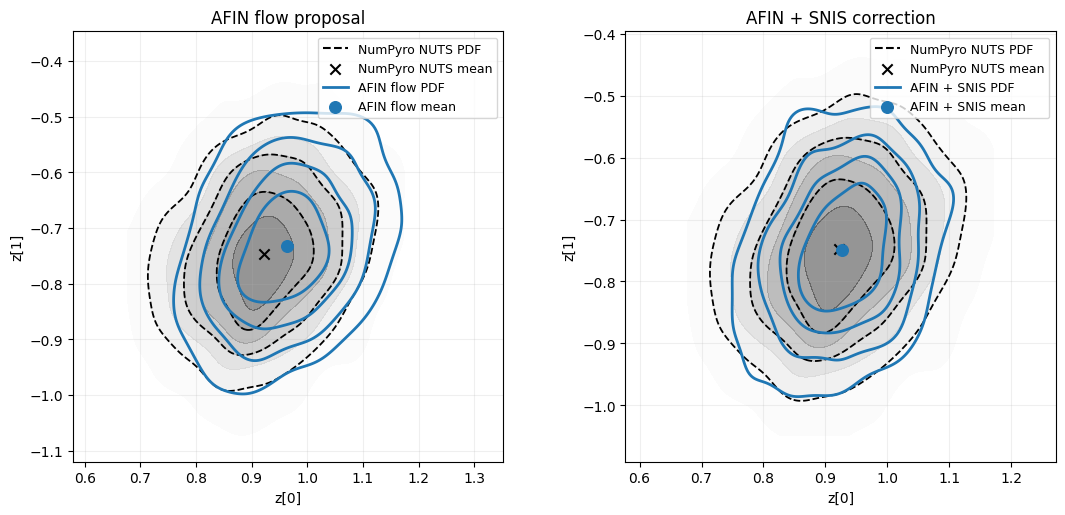

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))

plot_2d(proposal.target, proposal, reference, ax=axes[0], max_points=3_000)
axes[0].set_title("AFIN flow proposal")

plot_2d(proposal.target, snis.posterior, reference, ax=axes[1], max_points=3_000)
axes[1].set_title("AFIN + SNIS correction")

plt.tight_layout()

## IMH: AFIN proposal as a corrected Markov chain

Local MH can eventually converge, but it starts from a generic draw and has to search. AFIN-IMH starts from the learned proposal and corrects with the exact Metropolis-Hastings accept/reject step.

In [6]:
N_STEPS = 1_200
STEPS = np.unique(np.round(np.geomspace(1, N_STEPS, 28)).astype(int))

rw_states, rw_accept = run_random_walk_mh(proposal.target, n_steps=N_STEPS)
imh_states, imh_accept = run_afin_imh(flow, proposal.target, n_steps=N_STEPS)

ref_samples = reference.sample(N_STEPS, seed=123)
rw_trace = chain_metric_trace(rw_states, rw_accept, reference, STEPS, ref_samples=ref_samples)
imh_trace = chain_metric_trace(imh_states, imh_accept, reference, STEPS, ref_samples=ref_samples)

print("step 1")
print("  local MH:", rw_trace[0])
print("  AFIN-IMH:", imh_trace[0])
print("final")
print("  local MH:", rw_trace[-1])
print("  AFIN-IMH:", imh_trace[-1])

step 1
  local MH: {'step': 1, 'mean_error': 0.8962663412094116, 'sw2': 0.6181320266754577, 'in_region': 0.0, 'accept_rate': 1.0}
  AFIN-IMH: {'step': 1, 'mean_error': 0.09010446816682816, 'sw2': 0.051239581922895384, 'in_region': 1.0, 'accept_rate': 0.0}
final
  local MH: {'step': 1200, 'mean_error': 0.013300496153533459, 'sw2': 0.03067035551887965, 'in_region': 0.9141666889190674, 'accept_rate': 0.565}
  AFIN-IMH: {'step': 1200, 'mean_error': 0.008749433793127537, 'sw2': 0.010121963678514204, 'in_region': 0.9424999952316284, 'accept_rate': 0.8091666666666667}


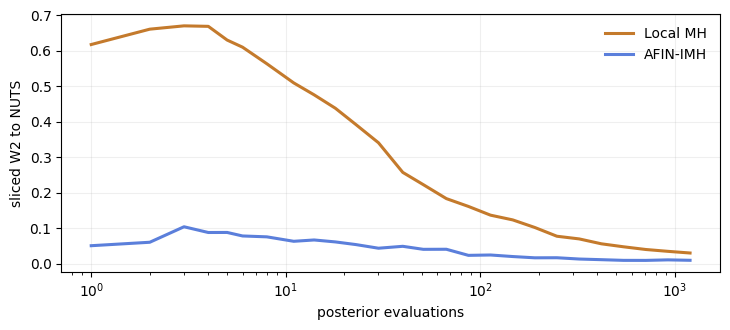

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot([m["step"] for m in rw_trace], [m["sw2"] for m in rw_trace], label="Local MH", color="#C47A2C", lw=2.2)
ax.plot([m["step"] for m in imh_trace], [m["sw2"] for m in imh_trace], label="AFIN-IMH", color="#5B7FDB", lw=2.2)
ax.set_xscale("log")
ax.set_xlabel("posterior evaluations")
ax.set_ylabel("sliced W2 to NUTS")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()

The README GIF is generated from the same comparison:

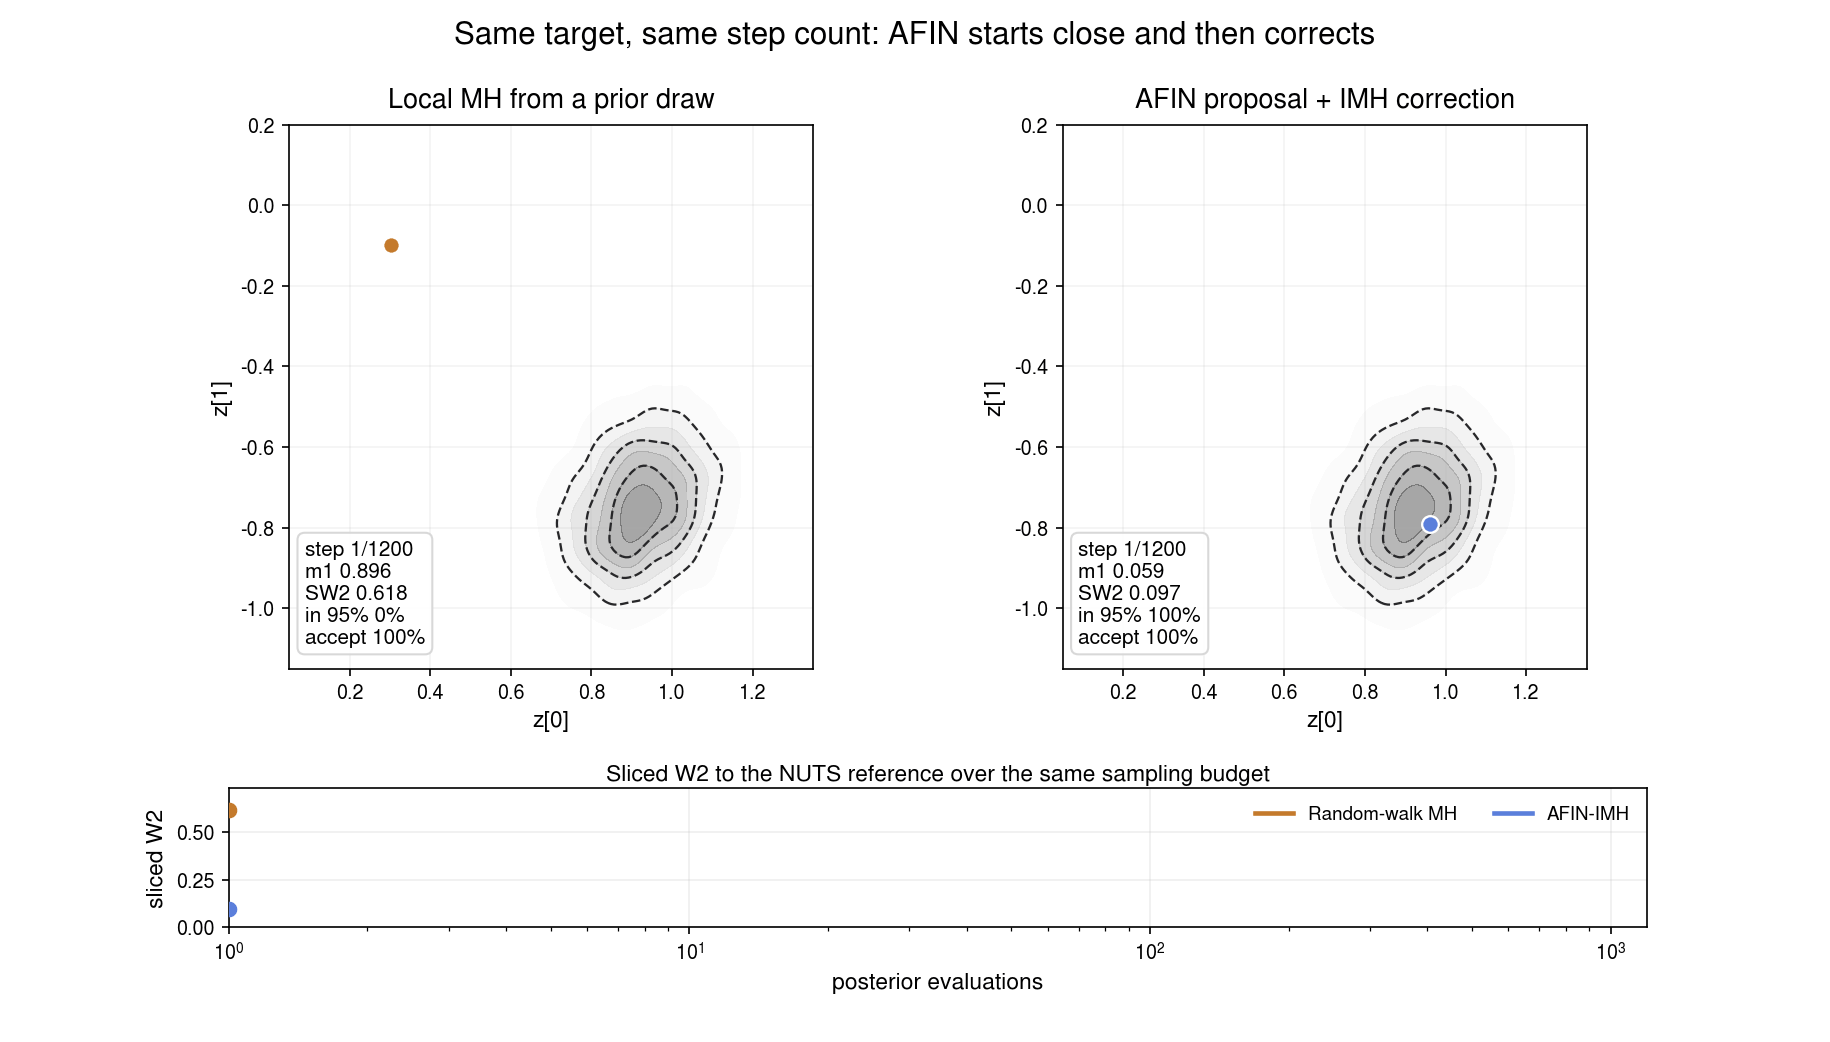

In [8]:
display(Image(filename=str(PROJECT_ROOT / "demo" / "assets" / "afin_vs_random_walk_mh.gif")))